# 3.2 Coalesce

Given a layout $A$, a coalesced layout $R$ is a layout that satisfies:

**Consistent integral domain:**
$$|R| = |A|, \tag{13}$$

**Flattened or integral shape:**
$$\text{depth}(R) \le 1, \tag{14}$$

**Consistent integral evaluation:**
$$\forall c \in \mathbb{Z}_{|A|},\ R(c) = A(c). \tag{15}$$

The coalesce operation "simplifies" the layout $A$ by treating it as a function over integers and potentially collapsing its shape to a shallower representation. While this process may remove rank and hierarchical information, modify coordinate sets, and merge multiple modes of $A$, it guarantees that the layout remains functionally equivalent as a mapping over its integral coordinates.

In [1]:
from tensor_layouts import Layout, size, cosize, rank, depth, mode, flatten, coalesce
from tensor_layouts.viz import draw_layout, show_layout

In practice, when referencing a coalesced layout, we typically mean the coalesced layout that achieves minimal rank.

As an example, the coalesced layout of $(2, (1, 6)) : (1, (6, 2))$ is $12 : 1$.

In [2]:
A1 = Layout((2, (1, 6)), (1, (6, 2)))
R1 = coalesce(A1)
print(f"A = {A1}")
print(f"coalesce(A) = {R1}")
print()

# Verify the three properties
assert size(R1) == size(A1), "Consistent integral domain"
assert depth(R1) <= 1, "Flattened or integral shape"
for c in range(size(A1)):
    assert R1(c) == A1(c), f"Evaluation mismatch at c={c}"
print(f"|R| = |A| = {size(A1)}")
print(f"depth(R) = {depth(R1)} <= 1")
print("R(c) = A(c) for all c in Z_|A| ✓")

A = (2, (1, 6)) : (1, (6, 2))
coalesce(A) = 12 : 1

|R| = |A| = 12
depth(R) = 0 <= 1
R(c) = A(c) for all c in Z_|A| ✓


Alternatively, this layout can be coalesced by-mode with Eq. (12), where we apply coalesce to each mode independently:

$$\text{coalesce}((2, (1, 6)) : (1, (6, 2)),\ \langle *, * \rangle) = \text{coalesce}((2 : 1,\ (1, 6) : (6, 2)),\ \langle *, * \rangle)$$
$$= (\text{coalesce}(2 : 1, *),\ \text{coalesce}((1, 6) : (6, 2), *))$$
$$= (\text{coalesce}(2 : 1),\ \text{coalesce}((1, 6) : (6, 2)))$$
$$= (2 : 1,\ 6 : 2)$$
$$= (2, 6) : (1, 2).$$

In [3]:
# By-mode coalesce: apply coalesce to each mode independently
mode0 = mode(A1, 0)  # 2 : 1
mode1 = mode(A1, 1)  # (1, 6) : (6, 2)
print(f"Mode 0: {mode0}  ->  coalesce: {coalesce(mode0)}")
print(f"Mode 1: {mode1}  ->  coalesce: {coalesce(mode1)}")

# Reconstruct by-mode coalesced layout
R1_bymode = Layout(coalesce(mode0), coalesce(mode1))
print(f"\nBy-mode coalesced: {R1_bymode}")
assert R1_bymode == Layout((2, 6), (1, 2))

Mode 0: 2 : 1  ->  coalesce: 2 : 1
Mode 1: (1, 6) : (6, 2)  ->  coalesce: 6 : 2

By-mode coalesced: (2, 6) : (1, 2)


Similarly, the rank-2 layout $((4, 3), 5) : ((15, 1), 3)$ coalesces to $(4, 15) : (15, 1)$ and the by-mode coalesced layout is $((4, 3), 5) : ((15, 1), 3)$ because the row and column layouts remain unchanged when individually coalesced.

In [4]:
A2 = Layout(((4, 3), 5), ((15, 1), 3))
R2 = coalesce(A2)
print(f"A = {A2}")
print(f"coalesce(A) = {R2}")
assert R2 == Layout((4, 15), (15, 1))

# Verify functional equivalence
for c in range(size(A2)):
    assert R2(c) == A2(c)
print(f"Functionally equivalent over all {size(A2)} integral coordinates.")
print()

# By-mode coalesce: each mode is already minimal
m0 = mode(A2, 0)  # (4, 3) : (15, 1) — not contiguous, can't merge
m1 = mode(A2, 1)  # 5 : 3 — already rank-1
print(f"Mode 0: {m0}  ->  coalesce: {coalesce(m0)}")
print(f"Mode 1: {m1}  ->  coalesce: {coalesce(m1)}")
print(f"By-mode coalesced: Layout({coalesce(m0)}, {coalesce(m1)})")
print("Modes are unchanged — by-mode coalesce equals original layout.")

A = ((4, 3), 5) : ((15, 1), 3)
coalesce(A) = (4, 15) : (15, 1)
Functionally equivalent over all 60 integral coordinates.

Mode 0: (4, 3) : (15, 1)  ->  coalesce: (4, 3) : (15, 1)
Mode 1: 5 : 3  ->  coalesce: 5 : 3
By-mode coalesced: Layout((4, 3) : (15, 1), 5 : 3)
Modes are unchanged — by-mode coalesce equals original layout.


The rank-2 layout $(4, (3, 5)) : (15, (1, 3))$ also coalesces to $(4, 15) : (15, 1)$ and the by-mode coalesced layout is $(4, 15) : (15, 1)$ because the second mode can be coalesced individually to $15 : 1$.

In [5]:
A3 = Layout((4, (3, 5)), (15, (1, 3)))
R3 = coalesce(A3)
print(f"A = {A3}")
print(f"coalesce(A) = {R3}")
assert R3 == Layout((4, 15), (15, 1))

# Verify functional equivalence
for c in range(size(A3)):
    assert R3(c) == A3(c)
print(f"Functionally equivalent over all {size(A3)} integral coordinates.")
print()

# By-mode: second mode (3, 5) : (1, 3) coalesces to 15 : 1
m0 = mode(A3, 0)
m1 = mode(A3, 1)
print(f"Mode 0: {m0}  ->  coalesce: {coalesce(m0)}")
print(f"Mode 1: {m1}  ->  coalesce: {coalesce(m1)}")
R3_bymode = Layout(coalesce(m0), coalesce(m1))
print(f"By-mode coalesced: {R3_bymode}")
assert R3_bymode == Layout((4, 15), (15, 1))

A = (4, (3, 5)) : (15, (1, 3))
coalesce(A) = (4, 15) : (15, 1)
Functionally equivalent over all 60 integral coordinates.

Mode 0: 4 : 15  ->  coalesce: 4 : 15
Mode 1: (3, 5) : (1, 3)  ->  coalesce: 15 : 1
By-mode coalesced: (4, 15) : (15, 1)


### Visualizing coalesce

Coalesce simplifies the layout representation without changing the underlying mapping. The logical grid looks the same — only the coordinate structure changes.

Before coalesce: (2, (1, 6)) : (1, (6, 2))


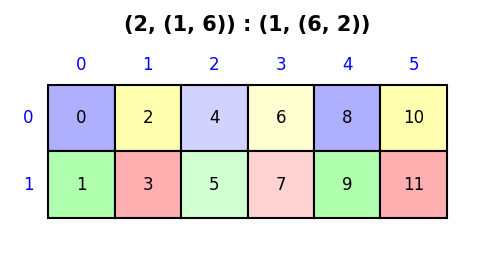


After coalesce: 12 : 1


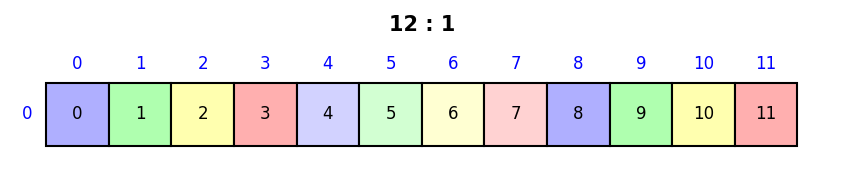

In [6]:
print("Before coalesce: (2, (1, 6)) : (1, (6, 2))")
draw_layout(A1, colorize=True)
print(f"\nAfter coalesce: {R1}")
draw_layout(R1, colorize=True)

Before coalesce: ((4, 3), 5) : ((15, 1), 3)


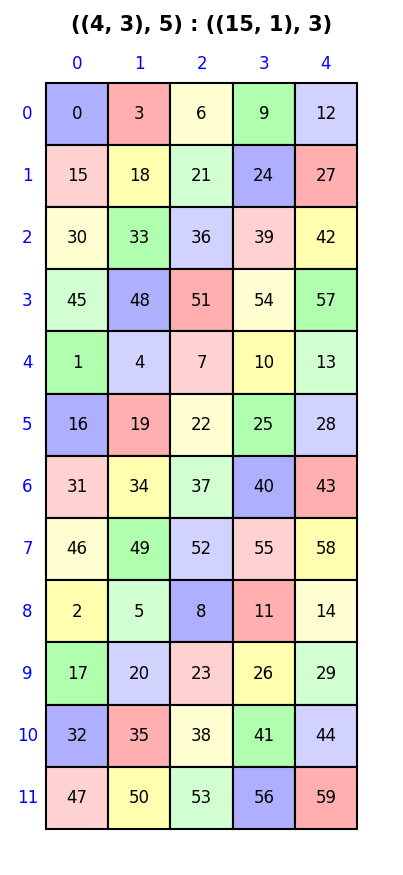


After coalesce: (4, 15) : (15, 1)


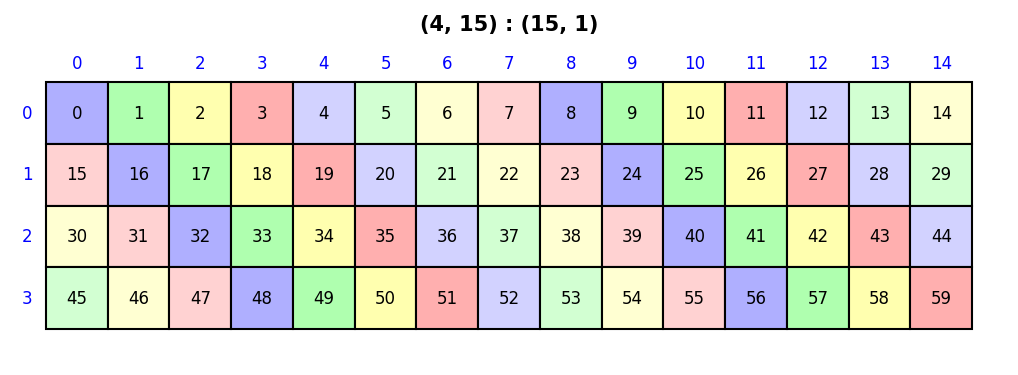

In [7]:
print(f"Before coalesce: {A2}")
draw_layout(A2, colorize=True)
print(f"\nAfter coalesce: {R2}")
draw_layout(R2, colorize=True)

### When does coalesce merge modes?

Coalesce merges two adjacent modes when the first mode's span equals the second mode's stride — i.e., the modes are contiguous in memory. When modes are not contiguous, they cannot be merged.

In [8]:
# Contiguous modes: stride of mode 1 = size of mode 0 * stride of mode 0
contiguous = Layout((4, 3), (1, 4))  # 4*1 = 4 = stride of mode 1 => can merge
print(f"Contiguous: {contiguous}  ->  coalesce: {coalesce(contiguous)}")
assert coalesce(contiguous) == Layout(12, 1)

# Non-contiguous: gap between modes
gapped = Layout((4, 3), (1, 8))  # 4*1 = 4 != 8 = stride of mode 1 => cannot merge
print(f"Gapped:     {gapped}  ->  coalesce: {coalesce(gapped)}")
assert coalesce(gapped) == Layout((4, 3), (1, 8))  # unchanged

# Non-contiguous: modes overlap
overlapping = Layout((4, 3), (1, 2))  # 4*1 = 4 != 2 = stride of mode 1 => cannot merge
print(f"Overlapping:{overlapping}  ->  coalesce: {coalesce(overlapping)}")
assert coalesce(overlapping) == Layout((4, 3), (1, 2))  # unchanged

# Column-major: naturally contiguous
colmajor = Layout((3, 4, 2), (1, 3, 12))
print(f"Col-major:  {colmajor}  ->  coalesce: {coalesce(colmajor)}")
assert coalesce(colmajor) == Layout(24, 1)

Contiguous: (4, 3) : (1, 4)  ->  coalesce: 12 : 1
Gapped:     (4, 3) : (1, 8)  ->  coalesce: (4, 3) : (1, 8)
Overlapping:(4, 3) : (1, 2)  ->  coalesce: (4, 3) : (1, 2)
Col-major:  (3, 4, 2) : (1, 3, 12)  ->  coalesce: 24 : 1


In [9]:
# Partial coalescing: only some adjacent modes merge
partial = Layout((2, 3, 5, 4), (1, 2, 10, 50))
# Modes 0,1 are contiguous (2*1=2), modes 2,3 are contiguous (5*10=50),
# but modes 1,2 are not (3*2=6 != 10)
print(f"Partial: {partial}  ->  coalesce: {coalesce(partial)}")

# Verify
R_partial = coalesce(partial)
for c in range(size(partial)):
    assert R_partial(c) == partial(c)
print(f"Functionally equivalent over all {size(partial)} coordinates.")

Partial: (2, 3, 5, 4) : (1, 2, 10, 50)  ->  coalesce: (6, 20) : (1, 10)
Functionally equivalent over all 120 coordinates.
